In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("Superstore.csv", encoding='latin1')
print(df.shape)
print(df.head())
print(df.dtypes)

(9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2013-152156  09-11-2013  12-11-2013    Second Class    CG-12520   
1       2  CA-2013-152156  09-11-2013  12-11-2013    Second Class    CG-12520   
2       3  CA-2013-138688  13-06-2013  17-06-2013    Second Class    DV-13045   
3       4  US-2012-108966  11-10-2012  18-10-2012  Standard Class    SO-20335   
4       5  US-2012-108966  11-10-2012  18-10-2012  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       4

In [2]:
# SQLite'a yükle
conn = sqlite3.connect("superstore.db")
df.to_sql("superstore", conn, if_exists="replace", index=False)

# Sorgu 1: Kategoriye göre toplam satış ve kar
query1 = """
SELECT Category,
       ROUND(SUM(Sales), 2) AS Total_Sales,
       ROUND(SUM(Profit), 2) AS Total_Profit,
       ROUND(SUM(Profit)/SUM(Sales)*100, 2) AS Profit_Margin
FROM superstore
GROUP BY Category
ORDER BY Total_Profit DESC
"""
df_category = pd.read_sql(query1, conn)
print("Kategoriye göre satış ve kar:")
print(df_category)

# Sorgu 2: Bölgeye göre performans
query2 = """
SELECT Region,
       ROUND(SUM(Sales), 2) AS Total_Sales,
       ROUND(SUM(Profit), 2) AS Total_Profit,
       ROUND(AVG(Discount)*100, 2) AS Avg_Discount_Pct
FROM superstore
GROUP BY Region
ORDER BY Total_Profit DESC
"""
df_region = pd.read_sql(query2, conn)
print("\nBölgeye göre performans:")
print(df_region)

# Sorgu 3: En çok zarar eden alt kategoriler
query3 = """
SELECT "Sub-Category",
       ROUND(SUM(Profit), 2) AS Total_Profit,
       ROUND(AVG(Discount)*100, 2) AS Avg_Discount_Pct
FROM superstore
GROUP BY "Sub-Category"
ORDER BY Total_Profit ASC
LIMIT 5
"""
df_loss = pd.read_sql(query3, conn)
print("\nEn çok zarar eden alt kategoriler:")
print(df_loss)

Kategoriye göre satış ve kar:
          Category  Total_Sales  Total_Profit  Profit_Margin
0       Technology    836154.03     145454.95          17.40
1  Office Supplies    719047.03     122490.80          17.04
2        Furniture    741999.80      18451.27           2.49

Bölgeye göre performans:
    Region  Total_Sales  Total_Profit  Avg_Discount_Pct
0     West    725457.82     108418.45             10.93
1     East    678781.24      91522.78             14.54
2    South    391721.91      46749.43             14.73
3  Central    501239.89      39706.36             24.04

En çok zarar eden alt kategoriler:
  Sub-Category  Total_Profit  Avg_Discount_Pct
0       Tables     -17725.48             26.13
1    Bookcases      -3472.56             21.11
2     Supplies      -1189.10              7.68
3    Fasteners        949.52              8.20
4     Machines       3384.76             30.61


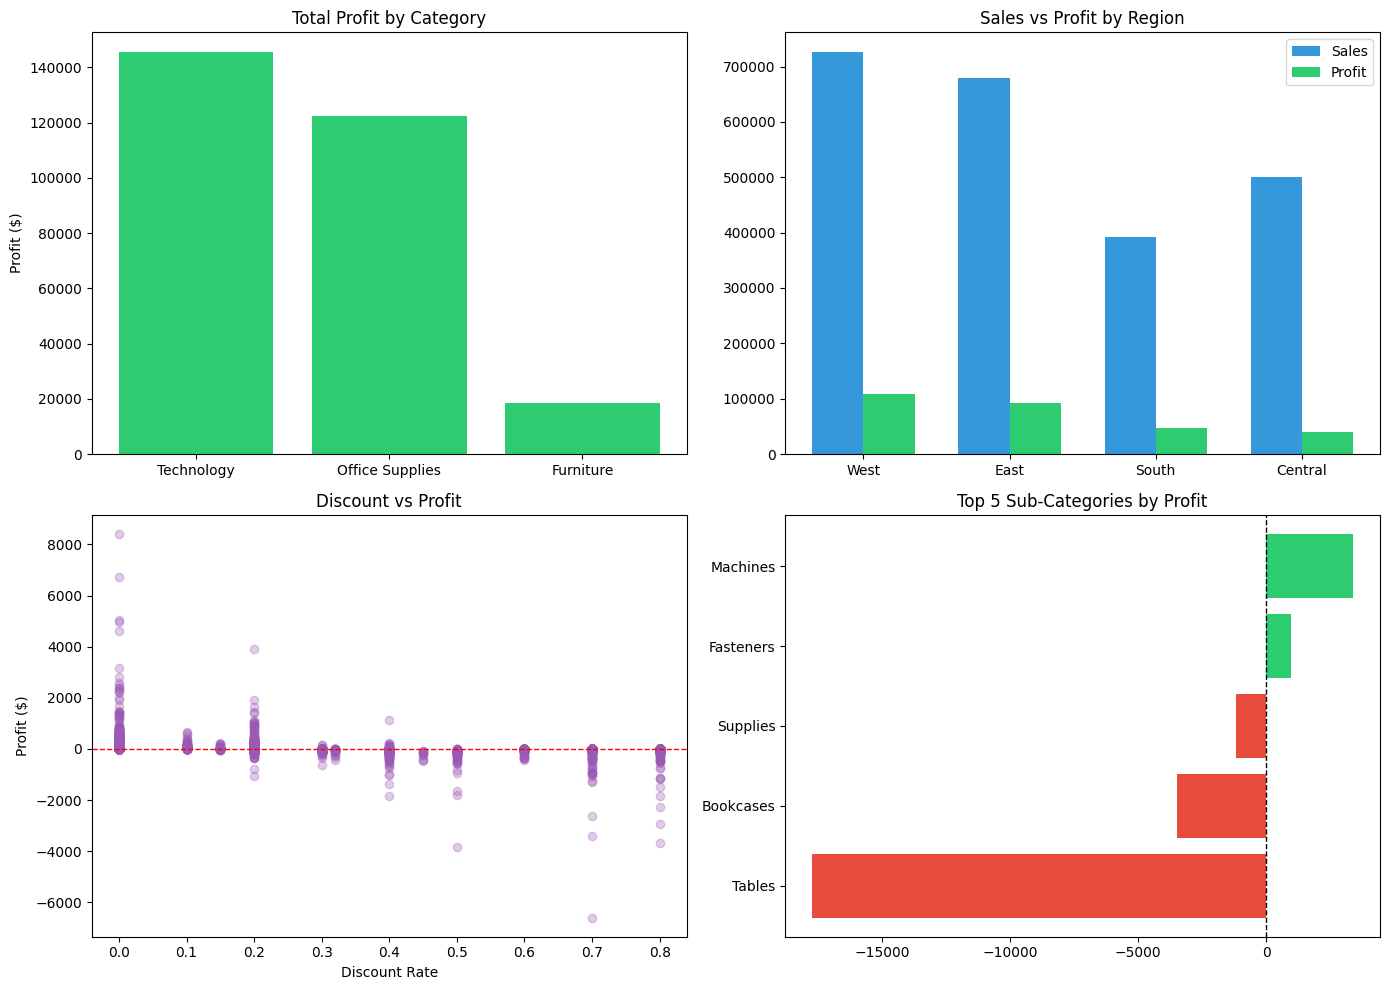

Grafik kaydedildi!


In [3]:
# Görsel 1: Kategoriye göre kar
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in df_category['Total_Profit']]
axes[0,0].bar(df_category['Category'], df_category['Total_Profit'], color=colors)
axes[0,0].set_title('Total Profit by Category')
axes[0,0].set_ylabel('Profit ($)')

# Görsel 2: Bölgeye göre satış vs kar
x = range(len(df_region))
width = 0.35
axes[0,1].bar([i - width/2 for i in x], df_region['Total_Sales'], width, label='Sales', color='#3498db')
axes[0,1].bar([i + width/2 for i in x], df_region['Total_Profit'], width, label='Profit', color='#2ecc71')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(df_region['Region'])
axes[0,1].set_title('Sales vs Profit by Region')
axes[0,1].legend()

# Görsel 3: İndirim vs Kar scatter
axes[1,0].scatter(df['Discount'], df['Profit'], alpha=0.3, color='#9b59b6')
axes[1,0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1,0].set_title('Discount vs Profit')
axes[1,0].set_xlabel('Discount Rate')
axes[1,0].set_ylabel('Profit ($)')

# Görsel 4: En çok zarar eden alt kategoriler
colors2 = ['#e74c3c' if x < 0 else '#2ecc71' for x in df_loss['Total_Profit']]
axes[1,1].barh(df_loss['Sub-Category'], df_loss['Total_Profit'], color=colors2)
axes[1,1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1,1].set_title('Top 5 Sub-Categories by Profit')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi!")

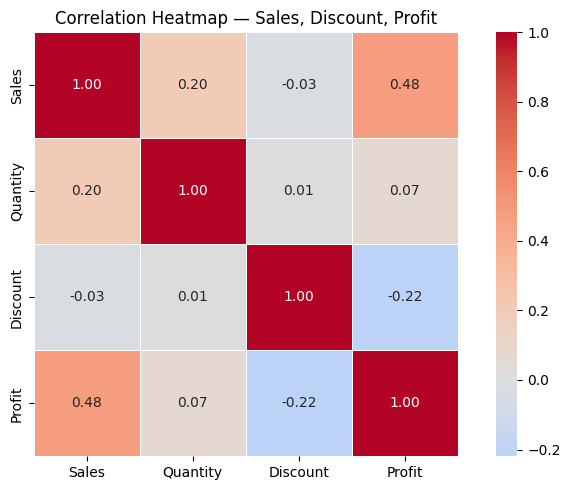

Heatmap kaydedildi!


In [4]:
# Görsel 5: Correlation Heatmap
plt.figure(figsize=(8, 5))
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Sales, Discount, Profit')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap kaydedildi!")